In [ ]:
import getopt
import sys
import gc
import os
sys.path.append("/home/atac2rna/program/atac2rna/Model/22_10_10")
from data_processing import *
import scanpy as sc
import anndata as ad
import pandas as pd

model_type = "basic"
data = "ma"
number = 4
file_path = "/home/atac2rna/data/atac2rna/model_output/22_10_12/batch_train/celltype_amp/ma/4"

RNA_data = sc.read_h5ad('/data/cabins/chenshengquan/scglue/Ma-2020-RNA.h5ad')
ATAC_data = sc.read_h5ad('/data/cabins/chenshengquan/scglue/Ma-2020-ATAC.h5ad')

############################################################
# Part 1 data processing
RNA_data = RNA_data_preprocessing(
    RNA_data,
    normalize_total=True,
    log1p=True,
    use_hvg=True,
    n_top_genes=3000,
    save_data=False,
    file_path=file_path,
    logging_path=file_path
    )
ATAC_data, divide_title, multiply_title, max_temp = ATAC_data_preprocessing(
    ATAC_data,
    binary_data=True,
    filter_features=True,
    fpeaks=0.005,
    tfidf=True,
    normalize=True,
    save_data=False,
    file_path=file_path,
    logging_path=file_path
)

1
2
3


# origin data with tfidf

In [1]:
import scanpy as sc

In [2]:
A_origin_processed = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/origin_ATAC_processed.h5ad')
A_origin_count = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/origin_ATAC_count.h5ad')

In [3]:
A_origin_count = A_origin_count[:, A_origin_processed.var.index] 

In [4]:
A_origin_count

View of AnnData object with n_obs × n_vars = 5927 × 166373
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'batch'
    var: 'chrom', 'chromStart', 'chromEnd', 'genome', 'n_counts'

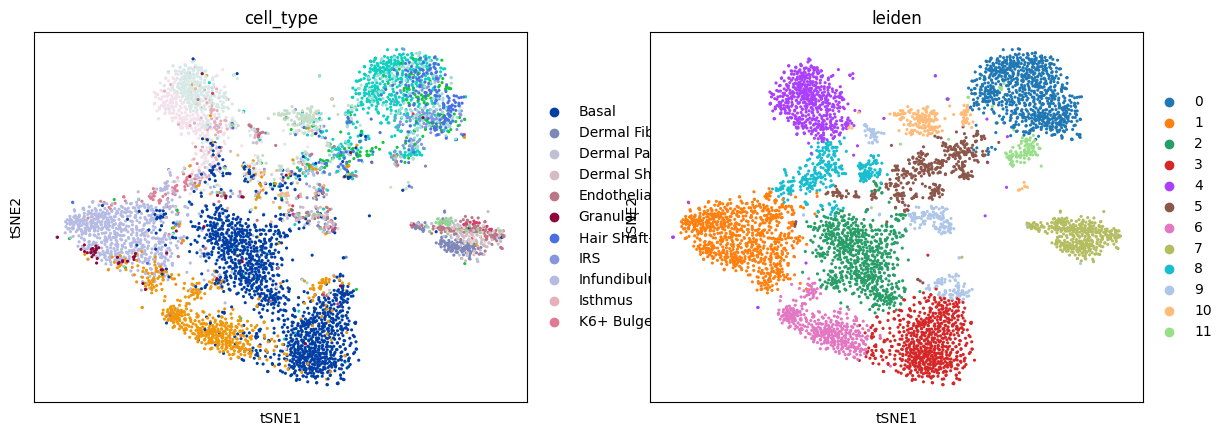

In [20]:
sc.pp.pca(A_origin_processed)
sc.pp.neighbors(A_origin_processed)
sc.tl.tsne(A_origin_processed)
sc.tl.leiden(A_origin_processed)
sc.pl.tsne(A_origin_processed, color=['cell_type', 'leiden'])

In [6]:
group1 = ['2']
group2 = ['3']
label = ['0' for i in range(len(A_origin_processed.obs.leiden))]
for i in range(len(A_origin_processed.obs.leiden)):
    if str(A_origin_processed.obs.leiden[i]) in group1:
        label[i] = '1'
    elif str(A_origin_processed.obs.leiden[i]) in group2:
        label[i] = '2'
    else:
        label[i] = '0'
A_origin_processed.obs['intergrate_leiden'] = label
A_origin_count.obs['intergrate_leiden'] = label

/tmp/ipykernel_3904520/3037734352.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  A_origin_count.obs['intergrate_leiden'] = label


/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


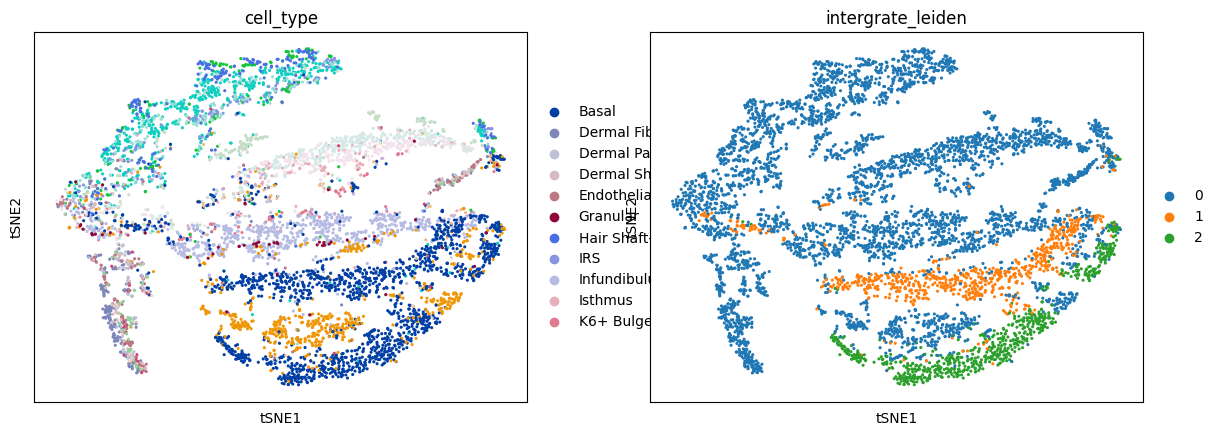

In [7]:
sc.pp.pca(A_origin_count)
sc.pp.neighbors(A_origin_count)
sc.tl.tsne(A_origin_count)
sc.tl.leiden(A_origin_count)
sc.pl.tsne(A_origin_count, color=['cell_type', 'intergrate_leiden'])

/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


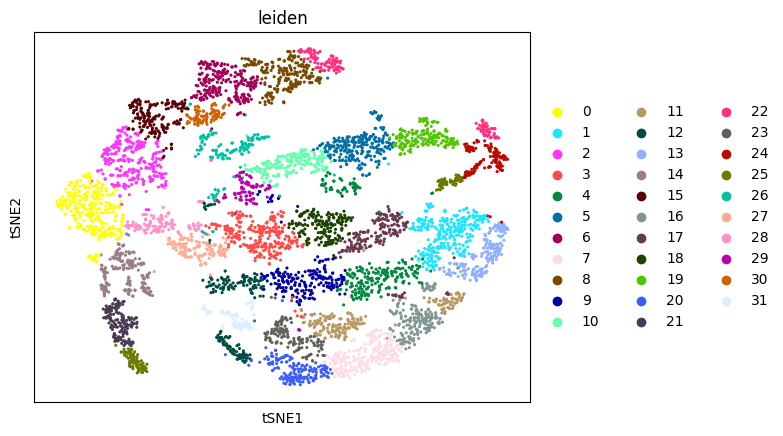

In [8]:
sc.tl.leiden(A_origin_count, resolution=2)
sc.pl.tsne(A_origin_count, color=['leiden'])

In [ ]:
group1 = ['1', '4', '9', '12']
group2 = ['20', '7', '16', '13']
label = ['0' for i in range(len(A_origin_processed.obs.leiden))]
for i in range(len(A_origin_processed.obs.leiden)):
    if str(A_origin_processed.obs.leiden[i]) in group1:
        label[i] = '1'
    elif str(A_origin_processed.obs.leiden[i]) in group2:
        label[i] = '2'
    else:
        label[i] = '0'
A_origin_processed.obs['intergrate_leiden'] = label

# predict

In [9]:
A_predict_processed = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/predict_ATAC_processed.h5ad')
A_predict_count = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/predict_ATAC_count_new.h5ad')

In [18]:
A_predict_count_processed = ATAC_data_preprocessing(
    ATAC_data,
    binary_data=True,
    filter_features=True,
    fpeaks=0.005,
    tfidf=True,
    normalize=True,
    save_data=False,
    file_path=file_path,
    logging_path=file_path
)[0]

1
2
3


In [20]:
A_predict_processed = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/predict_ATAC_processed.h5ad')
A_predict_count = sc.read_h5ad('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/GREAT/predict_ATAC_count.h5ad')

/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


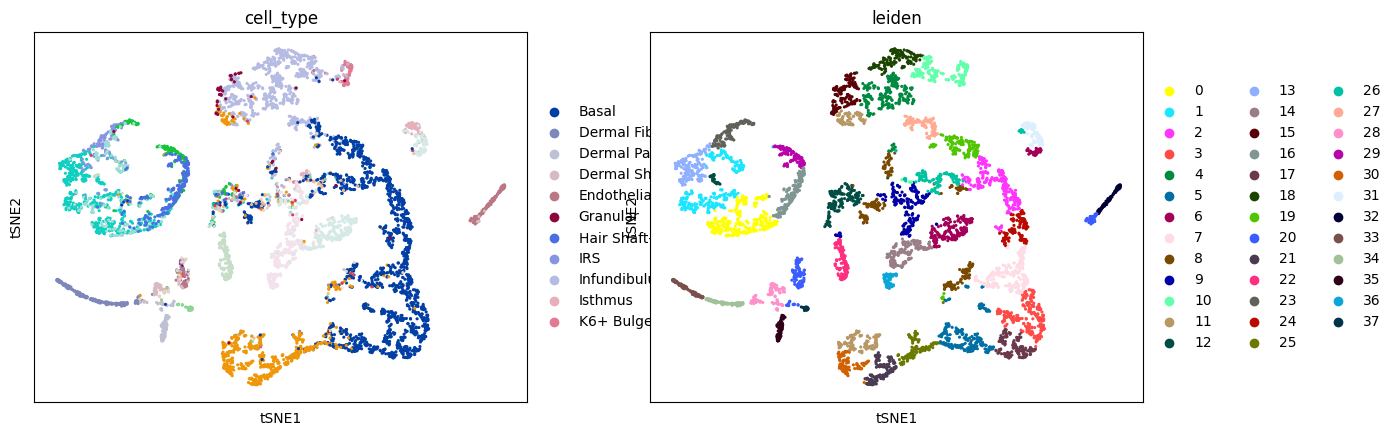

In [10]:
sc.pp.pca(A_predict_count)
sc.pp.neighbors(A_predict_count)
sc.tl.tsne(A_predict_count)
sc.tl.leiden(A_predict_count)
sc.pl.tsne(A_predict_count, color=['cell_type', 'leiden'])

In [11]:
A_predict_count.obs['origin_split'] = list(A_origin_count.obs['intergrate_leiden'])

/home/atac2rna/anaconda3/envs/atac2rna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


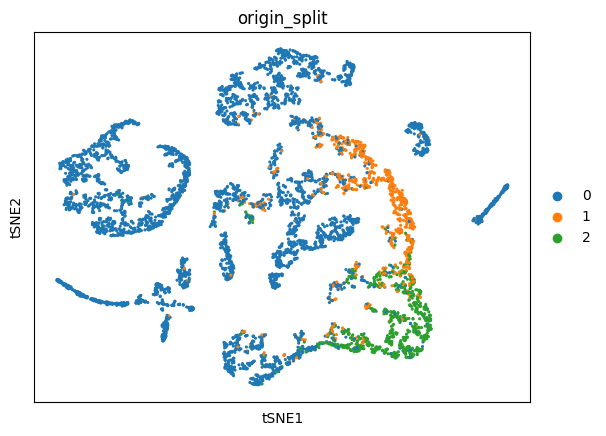

In [12]:
sc.pl.tsne(A_predict_count, color=['origin_split'])

In [16]:
group1 = ['24', '2', '19', '26']
group2 = ['3', '7', '17', '5']
label = ['0' for i in range(len(A_predict_count.obs.leiden))]
for i in range(len(A_predict_count.obs.leiden)):
    if str(A_predict_count.obs.leiden[i]) in group1:
        label[i] = '1'
    elif str(A_predict_count.obs.leiden[i]) in group2:
        label[i] = '2'
    else:
        label[i] = '0'
A_predict_count.obs['intergrate_leiden'] = label

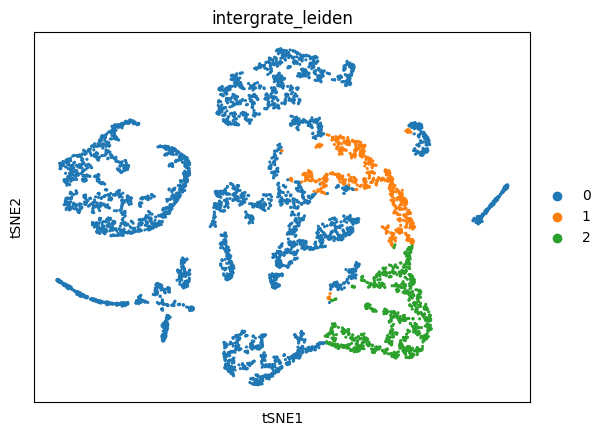

In [17]:
sc.pl.tsne(A_predict_count, color=['intergrate_leiden'])

# origin great

In [13]:
import pybedtools
import episcanpy.api as epi

In [14]:
epi.tl.rank_features(A_origin_count, 'intergrate_leiden', omic='ATAC', n_features=1000, reference='1', use_raw=False)
temp = list(A_origin_count.uns['rank_features_groups']['names'])
max_feature = 1000
group_list = [each[1] for each in temp][0:max_feature]
for each in group_list[0:max_feature]:
    print(each)
for i in range(max_feature):
    group_list[i]= group_list[i].replace("-","  ")
    group_list[i]= group_list[i].replace(":","  ")
peaks_str = '\n'.join(group_list)
test1 = pybedtools.BedTool(peaks_str, from_string=True)
test1.saveas('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/atac_ma_batch_origin_new.bed', trackline='track name = "ma batch 3"')

chr12:90781505-90781805
chr11:7446134-7446434
chr1:160060580-160060880
chr5:43711225-43711525
chr16:3820337-3820637
chr14:76145979-76146279
chr16:76336977-76337277
chr9:69227273-69227573
chr12:86046362-86046662
chr7:139972952-139973252
chr14:55924403-55924703
chr4:125134283-125134583
chr7:111466182-111466482
chr16:76409431-76409731
chr11:20325199-20325499
chr3:144980583-144980883
chr9:43323677-43323977
chr19:57473382-57473682
chr3:103412372-103412672
chr5:124221367-124221667
chr9:21715264-21715564
chr9:83061313-83061613
chr8:94148332-94148632
chr3:157695471-157695771
chr2:120164770-120165070
chr10:70199115-70199415
chr6:71555390-71555690
chr14:55933662-55933962
chr1:144306262-144306562
chr9:108044819-108045119
chr13:31251956-31252256
chr5:121156250-121156550
chr7:27145299-27145599
chr2:104732210-104732510
chr7:17014362-17014662
chr5:98844258-98844558
chr2:32250829-32251129
chr19:29384987-29385287
chr5:67410475-67410775
chr10:26703312-26703612
chr19:40844782-40845082
chr11:7404883-74051

<BedTool(/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/atac_ma_batch_origin_new.bed)>

# predict great

In [18]:
A_predict_count.var = A_origin_count.var

In [21]:
epi.tl.rank_features(A_predict_count, 'origin_split', omic='ATAC', n_features=1000, reference='1', use_raw=False)
temp = list(A_predict_count.uns['rank_features_groups']['names'])
max_feature = 1000
group_list = [each[1] for each in temp][0:max_feature]
for each in group_list[0:max_feature]:
    print(each)
for i in range(max_feature):
    group_list[i]= group_list[i].replace("-","  ")
    group_list[i]= group_list[i].replace(":","  ")
peaks_str = '\n'.join(group_list)
test1 = pybedtools.BedTool(peaks_str, from_string=True)
test1.saveas('/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/atac_ma_batch_predict_new.bed', trackline='track name = "ma batch 3"')

chr14:61556108-61556408
chr5:117361722-117362022
chr6:85264991-85265291
chr16:96467455-96467755
chr1:20863849-20864149
chr6:7845613-7845913
chr12:70829569-70829869
chr19:57523472-57523772
chr2:32574991-32575291
chr6:97305453-97305753
chr18:12102188-12102488
chr15:79288719-79289019
chr16:87700508-87700808
chr2:109890767-109891067
chr17:66523524-66523824
chr15:79028322-79028622
chr4:130836463-130836763
chr7:19358636-19358936
chr10:21995411-21995711
chrX:77795421-77795721
chr15:34239051-34239351
chr7:36695959-36696259
chr14:14634284-14634584
chr19:6941824-6942124
chr3:61340062-61340362
chr11:4203309-4203609
chr16:57483382-57483682
chr18:82064617-82064917
chr5:24841061-24841361
chr1:138618494-138618794
chr2:117122633-117122933
chr18:37837384-37837684
chr15:77821466-77821766
chr2:102433936-102434236
chr3:121884998-121885298
chr1:76276136-76276436
chr15:55866243-55866543
chr15:38710223-38710523
chr13:101693518-101693818
chr15:28059838-28060138
chr16:34691166-34691466
chr4:127358489-127358789

<BedTool(/home/atac2rna/data/atac2rna/model_output/22_10_12/GO_analysis/atac_ma_batch_predict_new.bed)>